In [1]:
from module import *

In [2]:
table_info("heart_rate")

nrows: 1154681
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      5 non-null      float64
 1   Time    5 non-null      str    
 2   Value   5 non-null      int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes


,Id,Time,Value
0,2.022484e+09,4/1/2016 7:54:00 AM,93
1,2.022484e+09,4/1/2016 7:54:05 AM,91
2,2.022484e+09,4/1/2016 7:54:10 AM,96
3,2.022484e+09,4/1/2016 7:54:15 AM,98
4,2.022484e+09,4/1/2016 7:54:20 AM,100


# Stats per Hour of Day

In [22]:
hourly = pd.read_sql("""
                    SELECT
                        STRFTIME('%H', date) AS hour,
                        id,
                        COUNT(*) AS count,
                        AVG(value) AS mean,
                        stdev(value) AS stdev,
                        MIN(value) AS min,
                        percentile(value, 0.25) AS p25,
                        percentile(value, 0.5) AS median,
                        percentile(value, 0.75) AS p75,
                        MAX(value) AS max
                    FROM hr24
                    GROUP BY hour, id
                    ORDER BY hour, id
                    """, conn)
hourly['hour'] = hourly['hour'].astype(int)
hourly

,hour,id,count,mean,stdev,min,p25,median,p75,max
0,00,2.026352e+09,258,62.263566,1.988368,57,61.0,62.0,63.0,68
1,00,2.347168e+09,3936,69.943598,6.300592,56,66.0,70.0,74.0,89
2,00,4.020333e+09,8832,77.099864,12.450231,56,67.0,74.0,88.0,108
3,00,4.558610e+09,1457,70.377488,8.621242,55,64.0,69.0,75.0,118
4,00,5.553957e+09,3764,60.211211,5.606626,50,56.0,59.0,63.0,83
...,...,...,...,...,...,...,...,...,...,...
285,23,6.391747e+09,336,84.354167,3.192741,76,82.0,84.0,87.0,94
286,23,6.775889e+09,1485,94.580471,10.491546,76,85.0,94.0,103.0,121
287,23,6.962181e+09,4353,70.076269,6.334224,55,66.0,69.0,73.0,98
288,23,8.792010e+09,2138,75.064546,6.518865,61,71.0,74.0,78.0,111


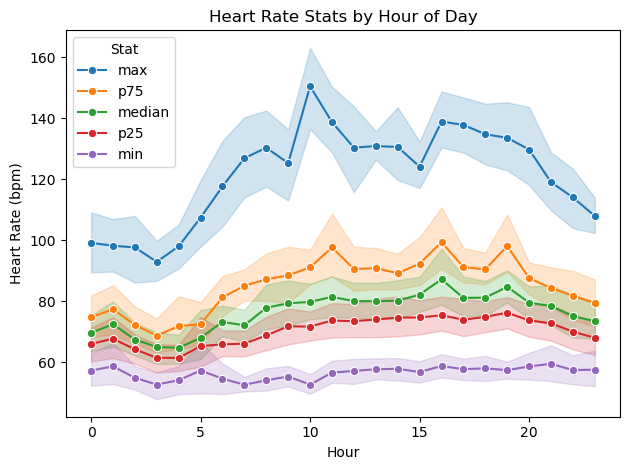

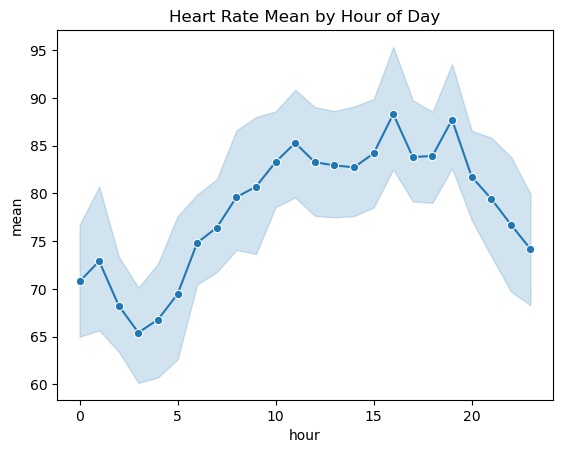

In [31]:
hourly_melt = hourly.melt(
    id_vars=['hour'],
    value_vars=['min', 'p25', 'median', 'p75', 'max'][::-1],
    var_name='stat',
    value_name='heart_rate'
)

sns.lineplot(data=hourly_melt, x='hour', y='heart_rate', hue='stat', marker='o')
plt.xlabel('Hour')
plt.ylabel('Heart Rate (bpm)')
plt.title('Heart Rate Stats')
plt.legend(title='Stat')
plt.tight_layout()
plt.show()

sns.lineplot(hourly, x='hour', y='mean', marker='o')
plt.title("Heart Rate Mean")
plt.show()

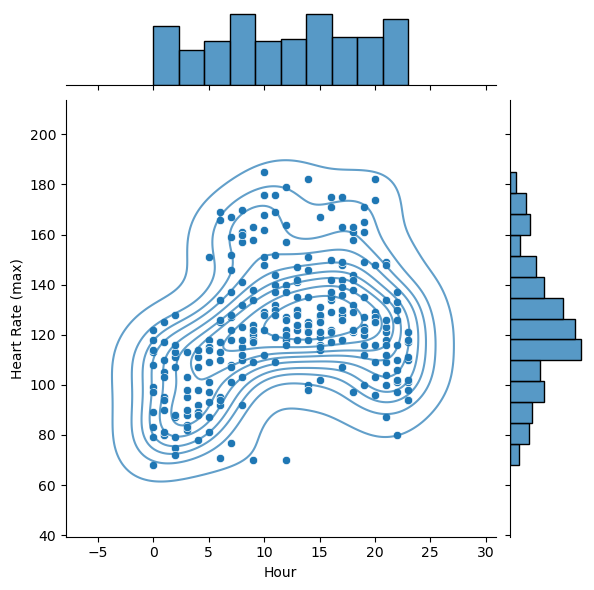

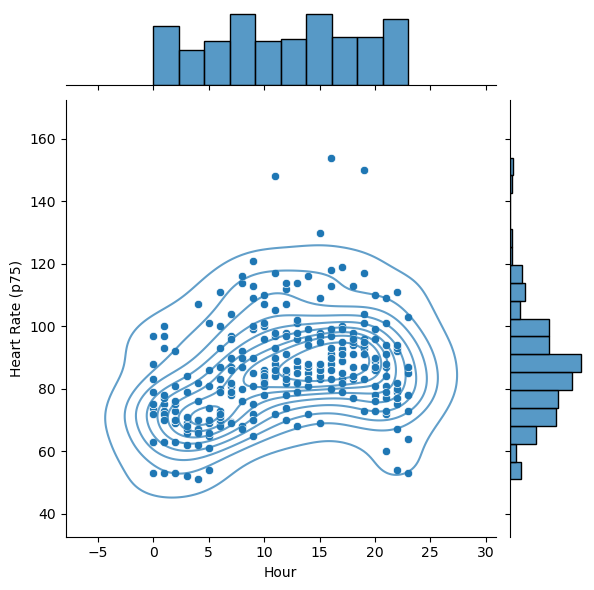

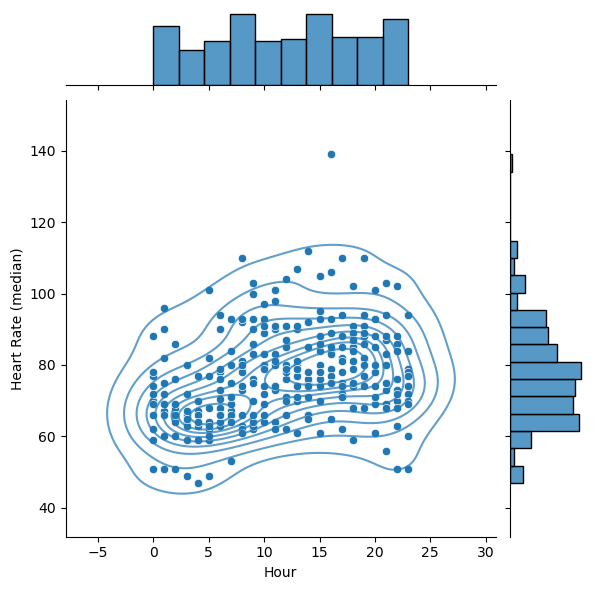

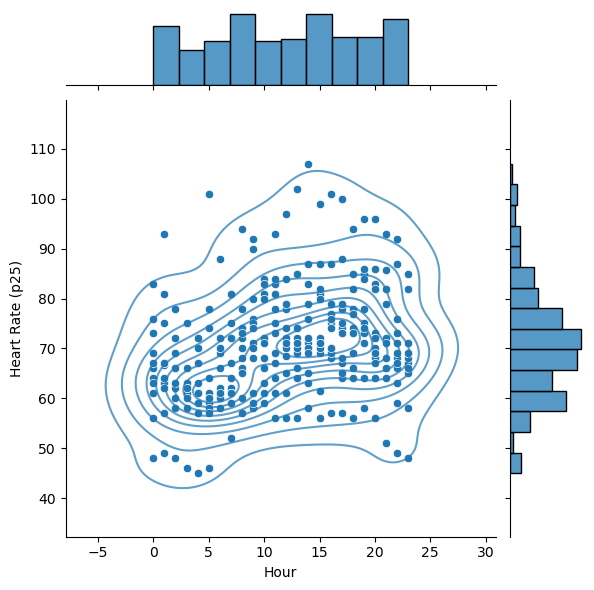

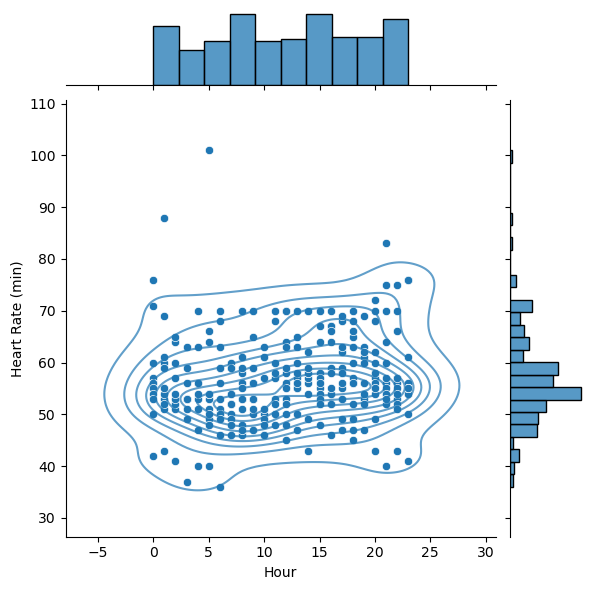

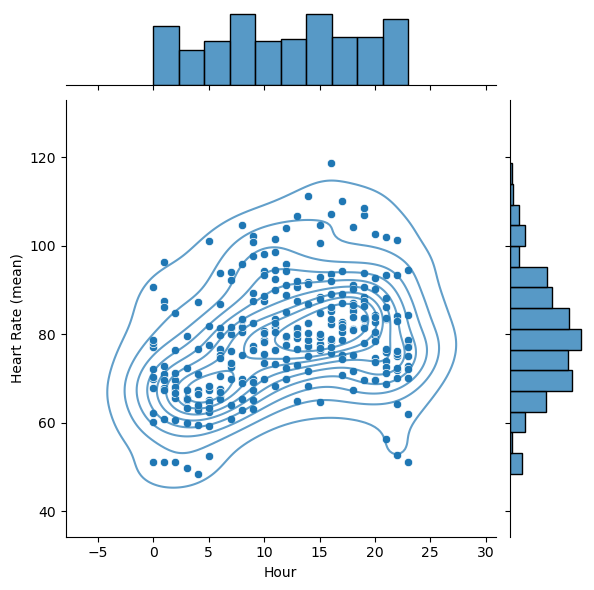

In [39]:
for col in hourly_melt['stat'].unique().tolist() + ['mean']:
    g = sns.jointplot(hourly, x='hour', y=col)
    g.plot_joint(sns.kdeplot, alpha=0.7)
    g.set_axis_labels(xlabel='Hour', ylabel=f"Heart Rate ({col})")
    plt.show()

# Stats per Day of Week

In [41]:
daily = pd.read_sql("""
                    SELECT
                        STRFTIME('%u', date) AS day_of_week,
                        id,
                        COUNT(*) AS count,
                        AVG(value) AS mean,
                        stdev(value) AS stdev,
                        MIN(value) AS min,
                        percentile(value, 0.25) AS p25,
                        percentile(value, 0.5) AS median,
                        percentile(value, 0.75) AS p75,
                        MAX(value) AS max
                    FROM hr24
                    GROUP BY day_of_week, id
                    ORDER BY day_of_week, id
                    """, conn)
daily['day_of_week'] = daily['day_of_week'].astype(int)
daily

,day_of_week,id,count,mean,stdev,min,p25,median,p75,max
0,1,2.022484e+09,9627,79.993664,18.245898,46,67.0,76.0,87.0,153
1,1,2.347168e+09,17342,74.157133,13.040896,54,65.0,71.0,79.0,140
2,1,4.020333e+09,55785,76.878068,12.762375,52,66.0,76.0,87.0,139
3,1,4.558610e+09,12339,82.850231,12.224514,55,75.0,84.0,91.0,147
4,1,5.553957e+09,17630,71.189507,16.077800,48,60.0,65.0,75.0,130
...,...,...,...,...,...,...,...,...,...,...
81,7,6.775889e+09,750,87.869333,9.750916,70,81.0,84.0,96.0,118
82,7,6.962181e+09,17426,79.699013,15.751383,53,68.0,76.0,89.0,141
83,7,7.007744e+09,11395,91.651163,16.909413,59,79.0,90.0,100.0,158
84,7,8.792010e+09,14053,79.915107,12.124408,49,73.0,79.0,87.0,128


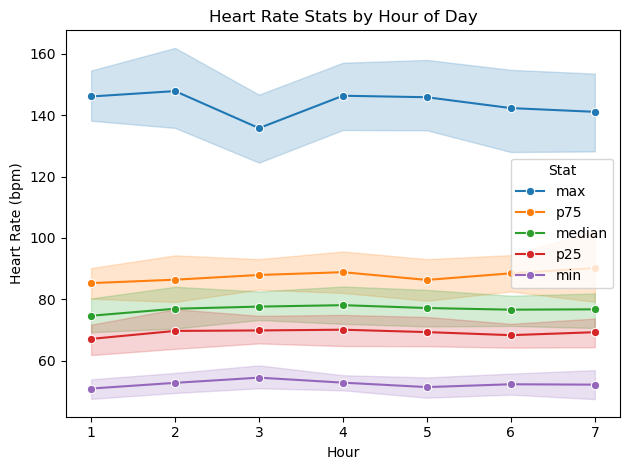

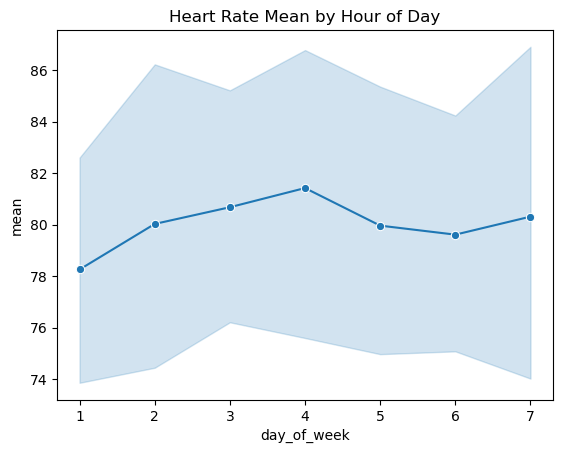

In [42]:
daily_melt = daily.melt(
    id_vars=['day_of_week'],
    value_vars=['min', 'p25', 'median', 'p75', 'max'][::-1],
    var_name='stat',
    value_name='heart_rate'
)

sns.lineplot(data=daily_melt, x='day_of_week', y='heart_rate', hue='stat', marker='o')
plt.xlabel('Hour')
plt.ylabel('Heart Rate (bpm)')
plt.title('Heart Rate Stats')
plt.legend(title='Stat')
plt.tight_layout()
plt.show()

sns.lineplot(daily, x='day_of_week', y='mean', marker='o')
plt.title("Heart Rate Mean")
plt.show()

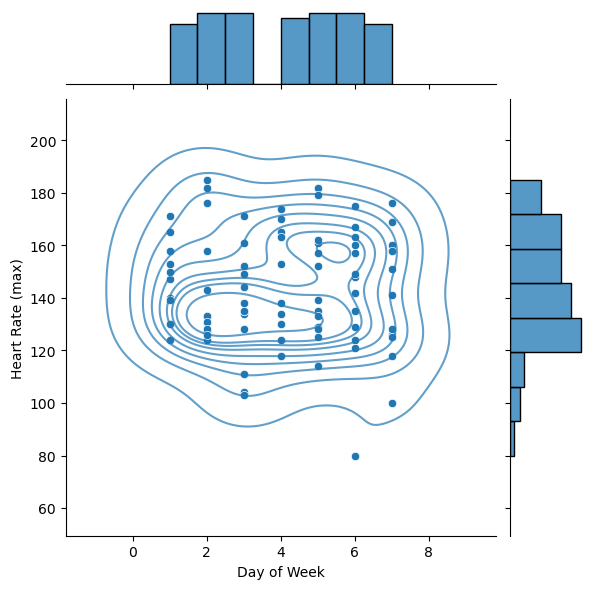

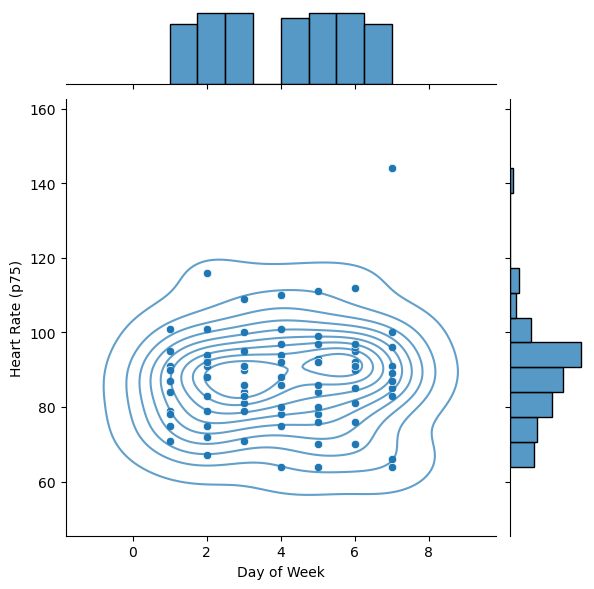

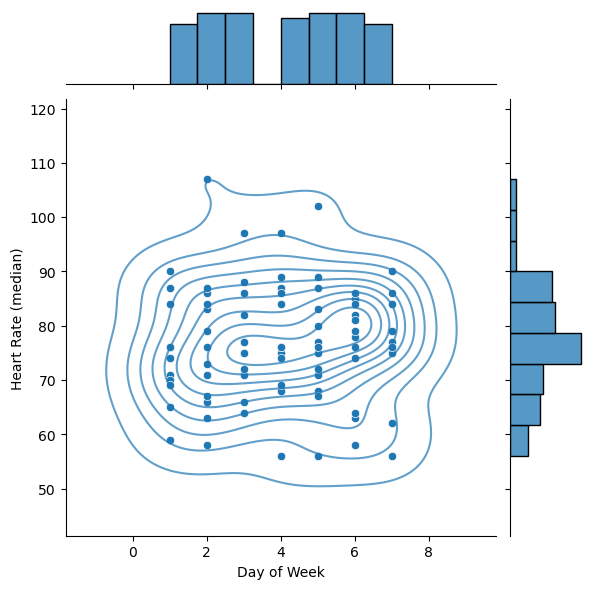

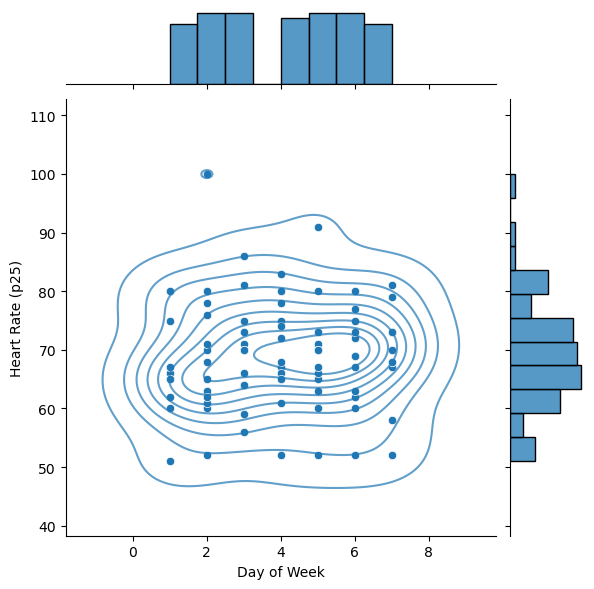

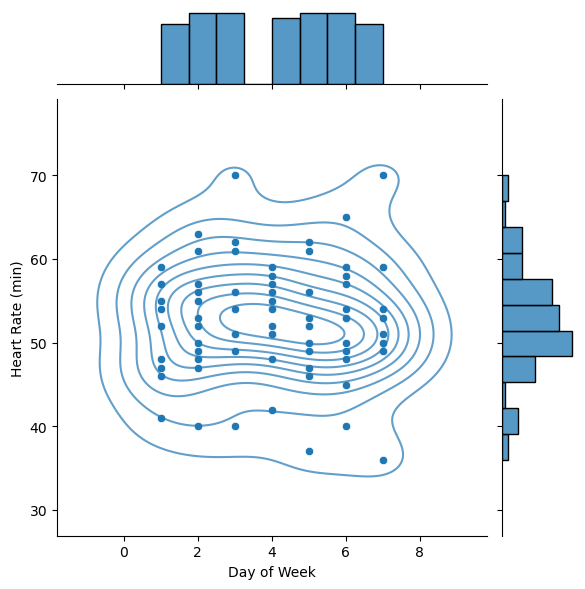

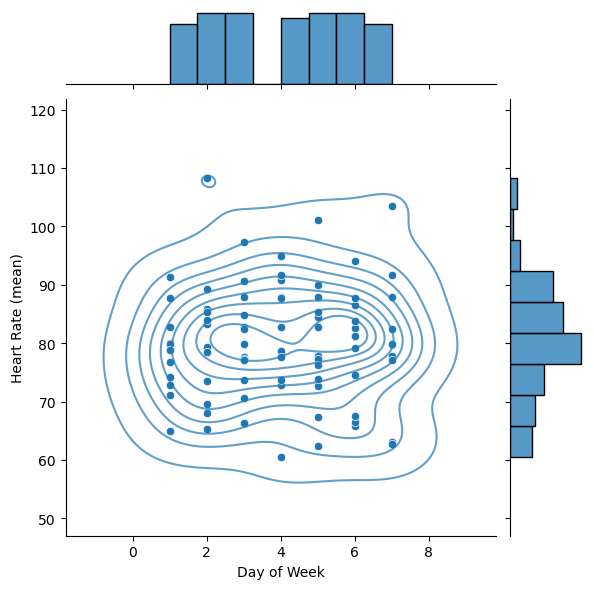

In [44]:
for col in daily_melt['stat'].unique().tolist() + ['mean']:
    g = sns.jointplot(daily, x='day_of_week', y=col)
    g.plot_joint(sns.kdeplot, alpha=0.7)
    g.set_axis_labels(xlabel='Day of Week', ylabel=f"Heart Rate ({col})")
    plt.show()